# Macro Model — BVAR with Enhanced Scenario Generation

Estimates a Bayesian VAR with Minnesota prior on stationary transforms.
Five enhancements over the base version:

1. **Structural long-run anchors** — derived from NAIRU, inflation target, neutral rate
2. **Triangular shock profiles** — shocks ramp up to peak then decay realistically
3. **Post-shock persistent anchor shifts** — recessions leave scars
4. **Cosine bridge** — smooth interpolation from BVAR endpoint to long-run anchor
5. **Interval calibration** — fan chart bands scaled to historical 90% coverage

**Why stationary transforms (not raw levels):**
Raw HPI and GDP levels are non-stationary (unit root), which causes the BVAR
companion matrix to have eigenvalue > 1 (unstable). The PD model selected variables
are already stationary transforms, so the BVAR projects these directly with no
downstream transformation needed.

**BVAR variables = PD model inputs (direct subset):**
- `unemployment_rate_log_diff_4_lag2` — UE YoY log growth, 2Q lag
- `hpi_cs_log_diff_1_lag2` — HPI CS QoQ log growth, 2Q lag
- `real_gdp_log_diff_4` — GDP YoY log growth, contemporaneous
- `fed_funds_rate_qoq_change` — Fed funds QoQ change
- `mortgage_rate_30y_qoq_change` — Mortgage rate QoQ change
- `yield_curve_spread` — 10y minus 2y Treasury spread

**Input:** `macro_panel_quarterly.csv`
**Output:** `bvar_results.pkl`, `scenarios.csv`

## 1. Imports

In [1]:
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from statsmodels.tsa.vector_ar.var_model import VAR as StatsVAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2. Load Panel

In [7]:
macro = pd.read_csv(
    'macro_panel_quarterly.csv',
    index_col=0,
    parse_dates=True
)
macro.index.name = 'quarter'
print(f'Panel: {macro.shape}  |  '
      f'{macro.index.min().date()} to {macro.index.max().date()}')

Panel: (427, 106)  |  1919-01-01 to 2025-07-01


## 3. Variable Selection

All six BVAR variables are stationary transforms — ADF-testable and stable in BVAR.
The three PD model variables are a direct subset of BVAR_VARS so scenario paths
feed into the PD projection notebook with no further transformation.

**Why these transforms?**
- `unemployment_rate_log_diff_4_lag2`: YoY log growth of UE lagged 2 quarters.
  Captures labour market momentum with realistic transmission lag to defaults.
- `hpi_cs_log_diff_1_lag2`: QoQ log growth of Case-Shiller HPI lagged 2 quarters.
  QoQ captures recent momentum; lag reflects time for price changes to affect defaults.
- `real_gdp_log_diff_4`: YoY log growth of real GDP contemporaneous.
  Broad activity measure; YoY smooths quarterly volatility.
- `fed_funds_rate_qoq_change`: conditioning variable for monetary policy channel.
- `mortgage_rate_30y_qoq_change`: direct housing finance cost.
- `yield_curve_spread`: recession predictor; inverted curve leads recessions 4-6 quarters.

| Variable | Channel | PD model input? |
|---|---|---|
| `unemployment_rate_log_diff_4_lag2` | Labour | **YES** |
| `hpi_cs_log_diff_1_lag2` | Housing | **YES** |
| `real_gdp_log_diff_4` | Activity | **YES** |
| `fed_funds_rate_qoq_change` | Monetary policy | No |
| `mortgage_rate_30y_qoq_change` | Housing finance | No |
| `yield_curve_spread` | Term structure | No |

In [8]:
BVAR_VARS = [
    'unemployment_rate_log_diff_4_lag2',
    'hpi_cs_log_diff_1_lag2',
    'real_gdp_log_diff_4',
    'fed_funds_rate_qoq_change',
    'mortgage_rate_30y_qoq_change',
    'yield_curve_spread',
]

# PD model uses exactly these three -- direct subset of BVAR_VARS
# No transformation needed at export -- scenarios.csv contains them directly
PD_VARS = [
    'unemployment_rate_log_diff_4_lag2',
    'hpi_cs_log_diff_1_lag2',
    'real_gdp_log_diff_4',
]

missing = [v for v in BVAR_VARS if v not in macro.columns]
if missing:
    print(f'MISSING: {missing}')
    print('Re-run Macro_clean_v2.ipynb with lag generation enabled.')
    print('These columns are generated in Section 6 of that notebook.')
else:
    print('All BVAR variables found.')
    print(f'PD model variables: {PD_VARS}')

bvar_data = macro[BVAR_VARS].dropna().copy()
bvar_data.index = pd.DatetimeIndex(bvar_data.index, freq='QS')
bvar_data_freq  = bvar_data.copy()

print(f'Sample: {bvar_data.index.min().date()} to {bvar_data.index.max().date()}')
print(f'Quarters: {len(bvar_data)}')

All BVAR variables found.
PD model variables: ['unemployment_rate_log_diff_4_lag2', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4']
Sample: 1987-10-01 to 2025-07-01
Quarters: 152


## 4. Stationarity Check
Verify all selected variables pass ADF. The two PD model inputs may show borderline
results over the full sample due to structural shifts -- this is acceptable as long
as the BVAR companion matrix is stable (checked in section 7).

In [9]:
print(f'{"Variable":<45}  {"ADF stat":>9}  {"p-value":>8}  {"n":>5}  {"Result"}')
print('-' * 82)
for var in BVAR_VARS:
    s = bvar_data[var].dropna()
    stat, pval, *_ = adfuller(s, autolag='AIC')
    result = 'stationary' if pval < 0.05 else 'borderline' if pval < 0.10 else 'NON-STATIONARY'
    print(f'{var:<45}  {stat:9.4f}  {pval:8.4f}  {len(s):>5}  {result}')

Variable                                        ADF stat   p-value      n  Result
----------------------------------------------------------------------------------
unemployment_rate_log_diff_4_lag2                -3.2518    0.0172    152  stationary
hpi_cs_log_diff_1_lag2                           -3.0510    0.0304    152  stationary
real_gdp_log_diff_4                              -3.0490    0.0306    152  stationary
fed_funds_rate_qoq_change                        -5.1436    0.0000    152  stationary
mortgage_rate_30y_qoq_change                    -10.0543    0.0000    152  stationary
yield_curve_spread                               -3.8008    0.0029    152  stationary


## 5. Multicollinearity Check (VIF)
VIF is computed on the quarterly macro data (one row per quarter) not on the
loan panel rows. VIF > 10 indicates problematic collinearity. If a variable
exceeds this threshold, remove it from `BVAR_VARS` above and re-run.

In [10]:
X_vif = bvar_data.dropna().values
vif   = pd.DataFrame({
    'variable': BVAR_VARS,
    'VIF':      [variance_inflation_factor(X_vif, i)
                 for i in range(len(BVAR_VARS))]
})
print(vif.sort_values('VIF', ascending=False).to_string(index=False))
if (vif['VIF'] > 10).any():
    print('\nWARNING: VIF > 10 detected. Consider removing the highest VIF variable.')
else:
    print('\nAll VIF < 10.')

                         variable      VIF
              real_gdp_log_diff_4 2.120201
               yield_curve_spread 1.622886
           hpi_cs_log_diff_1_lag2 1.574314
        fed_funds_rate_qoq_change 1.411441
unemployment_rate_log_diff_4_lag2 1.294118
     mortgage_rate_30y_qoq_change 1.286168

All VIF < 10.


## 6. Historical Plots

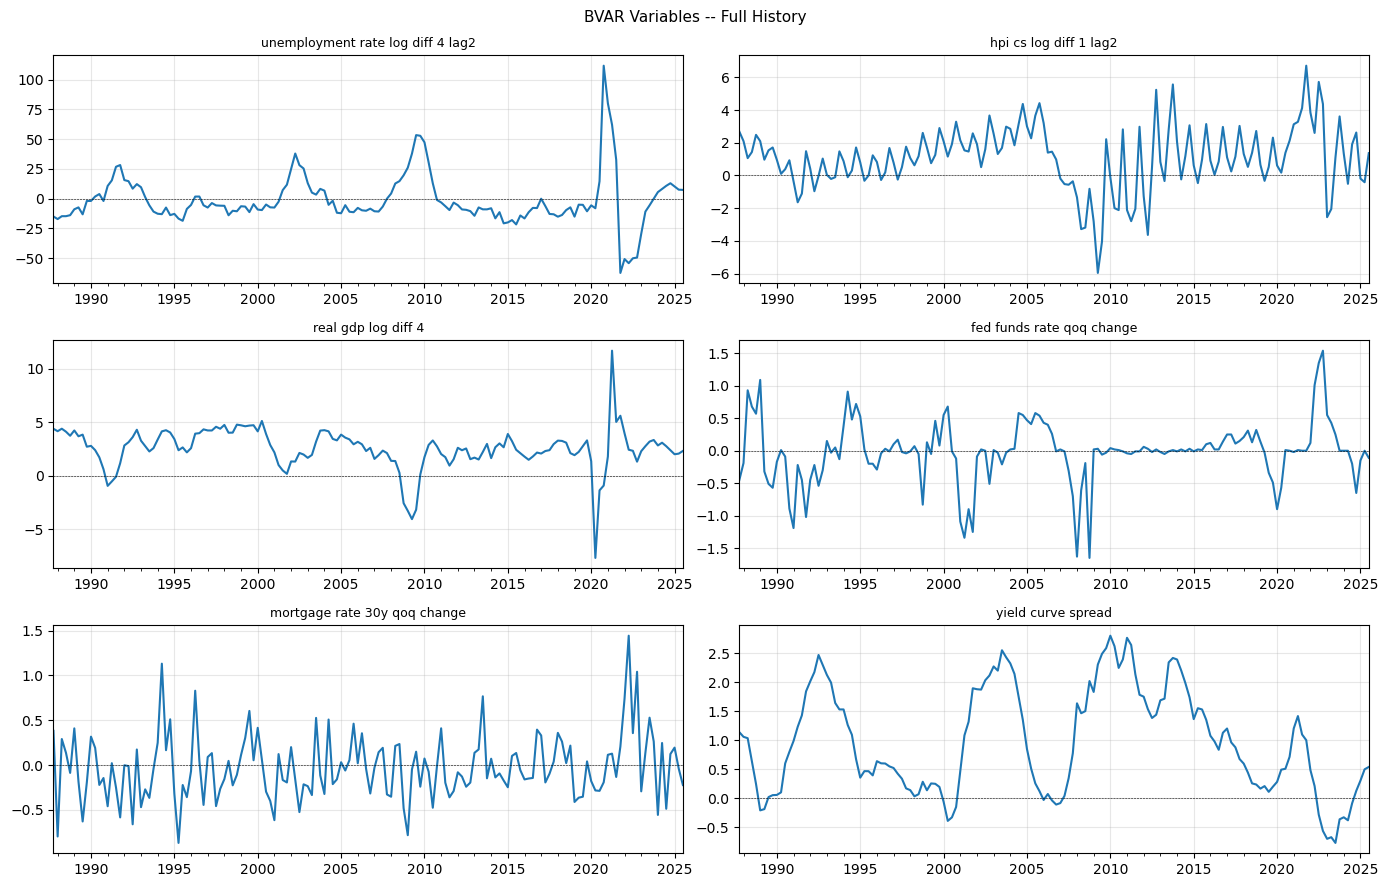

In [11]:
nrows = (len(BVAR_VARS) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, var in enumerate(BVAR_VARS):
    ax = axes[i]
    bvar_data[var].plot(ax=ax, linewidth=1.5)
    ax.set_title(var.replace('_', ' '), fontsize=9)
    ax.axhline(0, color='k', linewidth=0.4, linestyle='--')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

for ax in axes[len(BVAR_VARS):]:
    ax.set_visible(False)

fig.suptitle('BVAR Variables -- Full History', fontsize=11)
fig.tight_layout()
plt.show()

## 7. Lag Order Selection
`maxlags` is capped at `min(6, T/n - 2)` to prevent a singular residual covariance
at high lag orders. BIC is used -- more conservative than AIC.

In [12]:
n_vars  = len(BVAR_VARS)
maxlags = min(6, max(1, len(bvar_data) // n_vars - 2))
print(f'n_vars={n_vars},  T={len(bvar_data)},  maxlags capped at {maxlags}')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    lag_sel = StatsVAR(bvar_data).select_order(maxlags=maxlags)

print(lag_sel.summary())
P = max(1, lag_sel.bic)
print(f'Selected: p = {P}  (BIC)')

n_vars=6,  T=152,  maxlags capped at 6
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       4.238       4.360       69.25       4.288
1      -1.475     -0.6163      0.2290      -1.126
2      -2.428     -0.8343     0.08844      -1.781
3      -3.398     -1.069*     0.03373     -2.452*
4      -3.504     -0.4389     0.03069      -2.259
5      -3.746     0.05476     0.02455      -2.202
6     -3.806*      0.7309    0.02380*      -1.962
-------------------------------------------------
Selected: p = 3  (BIC)


## 8. BVAR -- Minnesota Prior
Normal-Inverse-Wishart conjugate gives a closed-form posterior -- no MCMC.

**Prior beliefs:**
- Each variable follows a random walk by default (own lag 1 = 1, cross lags = 0)
- Prior variance decays as 1/l^alpha for lag l (distant lags shrunk harder)
- Lambda controls overall tightness: smaller = more shrinkage toward the prior

In [13]:
LAM   = 0.15
ALPHA = 2.0


class MinnesotaBVAR:

    def __init__(self, lam=0.15, alpha=2.0, p=1):
        self.lam   = lam
        self.alpha = alpha
        self.p     = p

    def _build_X(self, Y, p):
        rows = []
        for t in range(p, len(Y)):
            row = [1.0]
            for lag in range(1, p + 1):
                row.extend(Y[t - lag])
            rows.append(row)
        return np.array(rows)

    def _build_prior(self, Y, n, p):
        k     = n * p + 1
        sigma = np.zeros(n)
        for i in range(n):
            yi  = Y[:, i]
            Xar = np.column_stack(
                [np.ones(len(yi) - p)] +
                [yi[p - l : len(yi) - l] for l in range(1, p + 1)]
            )
            b        = np.linalg.lstsq(Xar, yi[p:], rcond=None)[0]
            sigma[i] = max(np.std(yi[p:] - Xar @ b), 1e-6)

        M0 = np.zeros((k, n))
        for i in range(n):
            M0[1 + i, i] = 1.0

        v0    = np.zeros(k)
        v0[0] = 1e6
        for lag in range(1, p + 1):
            for j in range(n):
                pos     = 1 + (lag - 1) * n + j
                v_own   = (self.lam / lag ** self.alpha) ** 2
                v_cross = (self.lam * sigma.mean() /
                           (lag ** self.alpha * sigma[j])) ** 2
                v0[pos] = max(v_own, v_cross)

        return M0, np.diag(v0), sigma

    def fit(self, data):
        self.var_names = list(data.columns)
        Y    = data.values.astype(float)
        T, n = Y.shape
        p    = self.p
        self.n = n

        X     = self._build_X(Y, p)
        Yt    = Y[p:]
        k     = X.shape[1]
        self.k = k

        M0, V0, sigma = self._build_prior(Y, n, p)
        self.sigma_ar  = sigma

        nu0 = n + 2
        S0  = np.diag(sigma ** 2)

        V0i     = np.linalg.inv(V0)
        VTi     = V0i + X.T @ X
        self.VT = np.linalg.inv(VTi)
        self.MT = self.VT @ (V0i @ M0 + X.T @ Yt)

        nuT             = nu0 + len(Yt)
        self.ST         = (S0 + Yt.T @ Yt
                           + M0.T @ V0i @ M0
                           - self.MT.T @ VTi @ self.MT)
        self.nuT        = nuT
        self.Sigma_post = self.ST / (nuT - n - 1)
        self.Y_last     = Y[-p:]

        print(f'BVAR: {n} vars, p={p}, T={len(Yt)}, lam={self.lam}')
        return self

    def check_stability(self):
        n, p = self.n, self.p
        B    = self.MT[1:].T
        C    = np.zeros((n * p, n * p))
        C[:n, :] = B
        if p > 1:
            C[n:, :-n] = np.eye(n * (p - 1))
        eig    = np.abs(np.linalg.eigvals(C)).max()
        stable = eig < 1.0
        print(f'Max eigenvalue: {eig:.6f}  '
              f'{"Stable" if stable else "UNSTABLE -- tighten lam or reduce p"}')
        return stable, eig

    def forecast(self, h, shock=None):
        hist = list(self.Y_last)
        out  = []
        for t in range(h):
            x = np.concatenate([hist[-l] for l in range(1, self.p + 1)])
            y = self.MT[0] + self.MT[1:].T @ x
            if shock is not None and t == 0:
                y = y + np.array(shock)
            out.append(y)
            hist.append(y)
        return pd.DataFrame(out, columns=self.var_names)

    def forecast_draws(self, h, n_draws=300, shock=None, seed=42):
        rng   = np.random.default_rng(seed)
        paths = []
        for _ in range(n_draws):
            Sig = invwishart.rvs(df=self.nuT, scale=self.ST, random_state=rng)
            vec = rng.multivariate_normal(
                self.MT.flatten(order='F'), np.kron(Sig, self.VT)
            )
            Bd   = vec.reshape(self.k, self.n, order='F')
            hist = list(self.Y_last)
            path = []
            for t in range(h):
                x   = np.concatenate([hist[-l] for l in range(1, self.p + 1)])
                eps = rng.multivariate_normal(np.zeros(self.n), Sig)
                y   = Bd[0] + Bd[1:].T @ x + eps
                if shock is not None and t == 0:
                    y = y + np.array(shock)
                path.append(y)
                hist.append(y)
            paths.append(path)
        return np.array(paths)   # n_draws x h x n

## 9. Fit
Tries lam = 0.15 -> 0.10 -> 0.07 until the companion matrix is stable.
Falls back to p=1 as a last resort.

In [14]:
def fit_stable(data, p, lam_grid=(0.15, 0.10, 0.07), alpha=2.0):
    for lam in lam_grid:
        m       = MinnesotaBVAR(lam=lam, alpha=alpha, p=p).fit(data)
        ok, eig = m.check_stability()
        if ok:
            print(f'Using: p={p}, lam={lam}')
            return m, eig
    print('Falling back to p=1 ...')
    m       = MinnesotaBVAR(lam=lam_grid[0], alpha=alpha, p=1).fit(data)
    ok, eig = m.check_stability()
    return m, eig


bvar, max_eig = fit_stable(bvar_data, P, alpha=ALPHA)

BVAR: 6 vars, p=3, T=149, lam=0.15
Max eigenvalue: 0.881768  Stable
Using: p=3, lam=0.15


## 10. Posterior Coefficients

In [15]:
idx   = ['intercept'] + [
    f'{v}_lag{l+1}'
    for l in range(bvar.p)
    for v in BVAR_VARS
]
MT_df = pd.DataFrame(bvar.MT, columns=BVAR_VARS, index=idx)
print('Posterior mean coefficients:')
print(MT_df.round(4).to_string())

print('\nOwn-lag persistence (lag 1):')
for i, v in enumerate(BVAR_VARS):
    print(f'  {v:<45}: {bvar.MT[1 + i, i]:+.4f}')

Posterior mean coefficients:
                                        unemployment_rate_log_diff_4_lag2  hpi_cs_log_diff_1_lag2  real_gdp_log_diff_4  fed_funds_rate_qoq_change  mortgage_rate_30y_qoq_change  yield_curve_spread
intercept                                                         11.5428                  0.1400               0.4809                    -0.1347                       -0.0549              0.1927
unemployment_rate_log_diff_4_lag2_lag1                             0.6918                  0.0152               0.0035                     0.0017                       -0.0016              0.0034
hpi_cs_log_diff_1_lag2_lag1                                       -0.2125                  0.5792               0.0896                     0.0354                        0.0367              0.0006
real_gdp_log_diff_4_lag1                                          -0.5130                  0.0942               0.6311                    -0.0150                        0.0076            

## 11. In-Sample Fit

In [16]:
Y     = bvar_data.values.astype(float)
X     = bvar._build_X(Y, bvar.p)
Yt    = Y[bvar.p:]
resid = Yt - X @ bvar.MT

print(f'  {"Variable":<45}  {"RMSE":>8}  {"R2":>8}')
print('  ' + '-' * 64)
for i, var in enumerate(BVAR_VARS):
    rmse = np.sqrt(np.mean(resid[:, i] ** 2))
    ss_r = np.sum(resid[:, i] ** 2)
    ss_t = np.sum((Yt[:, i] - Yt[:, i].mean()) ** 2)
    print(f'  {var:<45}  {rmse:8.4f}  {1 - ss_r / ss_t:8.4f}')

  Variable                                           RMSE        R2
  ----------------------------------------------------------------
  unemployment_rate_log_diff_4_lag2                7.9053    0.8633
  hpi_cs_log_diff_1_lag2                           1.3730    0.5010
  real_gdp_log_diff_4                              1.1650    0.6407
  fed_funds_rate_qoq_change                        0.3242    0.5272
  mortgage_rate_30y_qoq_change                     0.3238    0.1604
  yield_curve_spread                               0.1935    0.9548


## 12. Out-of-Sample Validation
Re-fit BVAR at three historical cutoffs and compare h-step ahead forecast accuracy
against a random walk (each variable stays at its last observed value).
RMSE ratio < 1 means the BVAR beats the random walk.

In [17]:
def run_poos(data, p, lam, alpha, cutoffs, horizons=(1, 4, 8)):
    rows = []
    for cutoff in cutoffs:
        train = data[data.index <= cutoff]
        if len(train) < 20:
            continue
        try:
            m, _ = fit_stable(train, p, (lam,), alpha)
        except Exception as e:
            print(f'  {cutoff.date()}: {e}')
            continue
        last = train.iloc[-1].values
        for h in horizons:
            future = data[data.index > cutoff].iloc[:h]
            if len(future) < h:
                continue
            fc = m.forecast(h=h).values[-1]
            ac = future.values[-1]
            for i, var in enumerate(data.columns):
                rows.append({
                    'cutoff':   str(cutoff.date()),
                    'horizon':  h,
                    'variable': var,
                    'ratio':    abs(fc[i] - ac[i]) /
                                max(abs(last[i] - ac[i]), 1e-8)
                })
    return pd.DataFrame(rows)


cutoffs = [
    pd.Timestamp('2007-10-01'),   # pre-GFC
    pd.Timestamp('2012-10-01'),   # post-GFC recovery
    pd.Timestamp('2019-10-01'),   # pre-COVID expansion
]
cutoffs = [c for c in cutoffs if c <= bvar_data.index.max()]

poos_df = run_poos(bvar_data, bvar.p, bvar.lam, bvar.alpha, cutoffs)

if poos_df.empty:
    print('No results -- cutoffs outside sample.')
else:
    tbl = (
        poos_df.groupby(['variable', 'horizon'])['ratio']
        .mean().unstack('horizon').round(3)
    )
    tbl.columns = [f'h={c}' for c in tbl.columns]
    print('RMSE ratio (BVAR / random walk)  --  < 1 means BVAR wins')
    print(tbl.to_string())

BVAR: 6 vars, p=3, T=78, lam=0.15
Max eigenvalue: 0.932964  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=98, lam=0.15
Max eigenvalue: 0.909413  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=126, lam=0.15
Max eigenvalue: 0.908567  Stable
Using: p=3, lam=0.15
RMSE ratio (BVAR / random walk)  --  < 1 means BVAR wins
                                     h=1    h=4    h=8
variable                                              
fed_funds_rate_qoq_change          3.240  7.512  2.590
hpi_cs_log_diff_1_lag2             0.780  7.691  0.922
mortgage_rate_30y_qoq_change       3.019  1.928  2.662
real_gdp_log_diff_4                0.678  0.776  0.991
unemployment_rate_log_diff_4_lag2  0.949  3.066  1.453
yield_curve_spread                 0.876  0.701  1.002


## 13. Impulse Response Functions
Key check: a positive unemployment shock must produce a negative HPI growth response,
confirming the BVAR has learned the recession channel correctly.

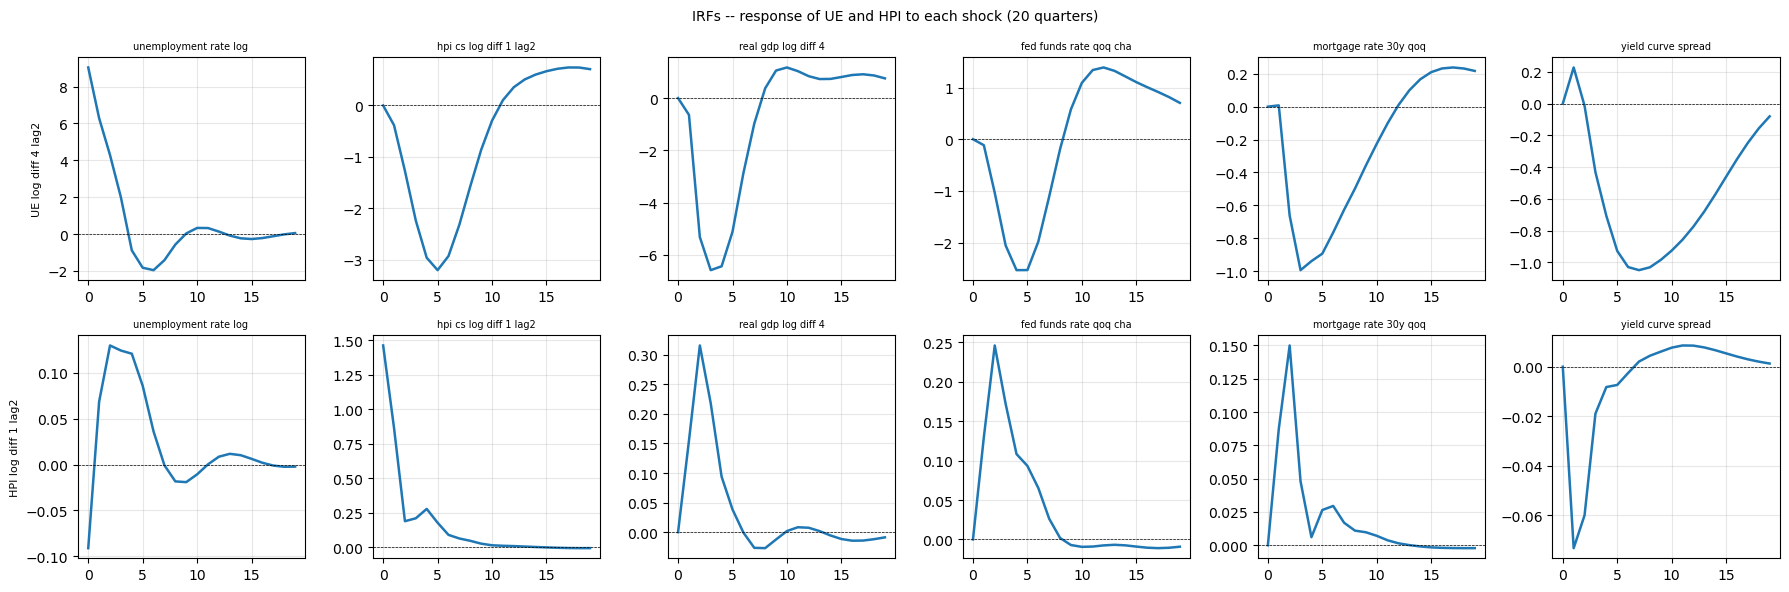

UE shock -> HPI response (peak): -0.0911  ✓ PASS
HPI shock -> UE response (peak): +0.7396  ✓ PASS


In [18]:
def compute_irf(bvar, n_periods=20):
    n    = bvar.n
    L    = np.linalg.cholesky(bvar.Sigma_post + np.eye(n) * 1e-8)
    irfs = {}
    for s in range(n):
        hist = [np.zeros(n)] * bvar.p
        res  = []
        for t in range(n_periods):
            x = np.concatenate([hist[-l] for l in range(1, bvar.p + 1)])
            y = bvar.MT[1:].T @ x
            if t == 0:
                y = y + L[:, s]
            res.append(y.copy())
            hist.append(y)
        irfs[bvar.var_names[s]] = np.array(res)
    return irfs


irfs   = compute_irf(bvar)
UE_VAR  = 'unemployment_rate_log_diff_4_lag2'
HPI_VAR = 'hpi_cs_log_diff_1_lag2'
ue_i   = BVAR_VARS.index(UE_VAR)
hpi_i  = BVAR_VARS.index(HPI_VAR)

fig, axes = plt.subplots(2, len(BVAR_VARS), figsize=(18, 6))

for col, shock_var in enumerate(BVAR_VARS):
    for row, resp_var, label in [
        (0, UE_VAR,  'UE log diff 4 lag2'),
        (1, HPI_VAR, 'HPI log diff 1 lag2'),
    ]:
        ax = axes[row, col]
        ri = BVAR_VARS.index(resp_var)
        ax.plot(irfs[shock_var][:, ri], linewidth=1.8)
        ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
        ax.set_title(shock_var.replace('_', ' ')[:22], fontsize=7)
        if col == 0:
            ax.set_ylabel(label, fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle('IRFs -- response of UE and HPI to each shock (20 quarters)', fontsize=10)
fig.tight_layout()
plt.show()

# Key sign check
ue_hpi  = irfs[UE_VAR][:, hpi_i].min()
hpi_ue  = irfs[HPI_VAR][:, ue_i].max()
print(f'UE shock -> HPI response (peak): {ue_hpi:+.4f}  '
      f'{chr(10003) + " PASS" if ue_hpi < 0 else chr(10007) + " FAIL -- expected negative"}')
print(f'HPI shock -> UE response (peak): {hpi_ue:+.4f}  '
      f'{chr(10003) + " PASS" if hpi_ue > 0 else chr(10007) + " FAIL -- expected positive"}')

## 14. Scenarios

**Three-phase structure:**
- Phase 1 (12 quarters): BVAR propagates the shock with triangular profile
- Phase 2: cosine bridge from BVAR endpoint to scarred long-run anchor (no kink)
- Phase 3: flat at long-run anchor for remaining quarters

**Shock magnitudes** are in units of the stationary transforms:
- UE log diff 4: pp change in YoY log growth (~= pp change in YoY level growth)
- HPI log diff 1: pp change in QoQ log growth (~0.25pp = ~1pp annual)
- GDP log diff 4: pp change in YoY log growth

**Calibration to historical episodes:**
- Mild: 2001 recession — UE rose ~1.5pp YoY, HPI slowed ~0.75pp QoQ
- Severe: GFC — UE rose ~4pp YoY, HPI fell ~2pp QoQ (~-8% annual)

**Post-shock scarring:** recessions leave permanent anchor shifts:
- Mild: HPI long-run down 0.05pp QoQ (≈ -0.2pp annual)
- Severe: HPI long-run down 0.12pp QoQ (≈ -0.5pp annual), yield curve +0.2pp

In [19]:
TOTAL_H = 120   # 30 years

# ── Structural long-run anchors ───────────────────────────────────────
# Anchors are on stationary transforms, derived from economic theory.
#
# UE log diff 4:    0.0  -- neutral: no YoY change in unemployment (at NAIRU)
# HPI log diff 1:   0.74 -- ~3% annual HPI growth / 4 quarters
#                          (inflation 2.1% + real income growth ~1% - supply drag)
# Real GDP log d4:  2.0  -- long-run potential growth ~2% YoY
# Fed funds QoQ:    0.0  -- stable at neutral rate (no change)
# Mortgage QoQ:     0.0  -- stable
# Yield curve:      1.5  -- historical average 10y-2y spread ~1.5pp

post2010     = bvar_data[bvar_data.index >= '2010-01-01']
sample_means = {v: float(post2010[v].mean()) for v in BVAR_VARS}

long_run = {
    'unemployment_rate_log_diff_4_lag2':  0.0,
    'hpi_cs_log_diff_1_lag2':             0.74,
    'real_gdp_log_diff_4':                2.0,
    'fed_funds_rate_qoq_change':          0.0,
    'mortgage_rate_30y_qoq_change':       0.0,
    'yield_curve_spread':                 1.5,
}

print('Long-run anchors (structural vs post-2010 sample mean):')
print(f'{"Variable":<45}  {"Anchor":>8}  {"Sample mean":>12}')
print('-' * 70)
for v in BVAR_VARS:
    print(f'  {v:<45}  {long_run[v]:8.4f}  {sample_means[v]:12.4f}')

Long-run anchors (structural vs post-2010 sample mean):
Variable                                         Anchor   Sample mean
----------------------------------------------------------------------
  unemployment_rate_log_diff_4_lag2                0.0000       -4.0361
  hpi_cs_log_diff_1_lag2                           0.7400        1.2429
  real_gdp_log_diff_4                              2.0000        2.3662
  fed_funds_rate_qoq_change                        0.0000        0.0651
  mortgage_rate_30y_qoq_change                     0.0000        0.0261
  yield_curve_spread                               1.5000        0.9922


In [20]:
def make_shock(**kwargs):
    return [kwargs.get(v, 0.0) for v in BVAR_VARS]


def triangular_profile(peak_value, ramp_quarters, peak_quarters, decay_quarters):
    """
    Realistic recession shock shape:
    - Ramps linearly to peak over ramp_quarters
    - Holds at peak for peak_quarters
    - Decays linearly back to zero over decay_quarters
    """
    profile = []
    for t in range(1, ramp_quarters + 1):
        profile.append(peak_value * t / ramp_quarters)
    for _ in range(peak_quarters):
        profile.append(peak_value)
    for t in range(1, decay_quarters + 1):
        profile.append(peak_value * (1 - t / decay_quarters))
    return profile


# Shock magnitudes are on stationary transforms:
# UE log diff 4 units: pp YoY log growth
# HPI log diff 1 units: pp QoQ log growth (~0.75pp = ~3pp annual)
# GDP log diff 4 units: pp YoY log growth

SCENARIOS = {
    'baseline': {
        'label':    'Baseline',
        'color':    'tab:blue',
        'shock':    make_shock(),
        'profile':  None,
        'phase1':   12,
        'revert':   20,
        'scarring': {},
    },
    'mild': {
        'label':    'Mild Recession',
        'color':    'tab:orange',
        'shock':    make_shock(**{
            'unemployment_rate_log_diff_4_lag2':  1.5,
            'hpi_cs_log_diff_1_lag2':            -0.75,
            'real_gdp_log_diff_4':               -1.0,
        }),
        'profile': {
            'unemployment_rate_log_diff_4_lag2':  triangular_profile(1.5,  4, 2, 6),
            'hpi_cs_log_diff_1_lag2':             triangular_profile(-0.75, 4, 2, 6),
            'real_gdp_log_diff_4':                triangular_profile(-1.0,  4, 2, 6),
        },
        'phase1':   12,
        'revert':   16,
        'scarring': {
            'hpi_cs_log_diff_1_lag2':  -0.05,  # ~-0.2pp annual HPI growth scar
        },
    },
    'severe': {
        'label':    'Severe Stress',
        'color':    'tab:red',
        'shock':    make_shock(**{
            'unemployment_rate_log_diff_4_lag2':  4.0,
            'hpi_cs_log_diff_1_lag2':            -2.0,
            'real_gdp_log_diff_4':               -3.0,
            'fed_funds_rate_qoq_change':           1.0,
        }),
        'profile': {
            'unemployment_rate_log_diff_4_lag2':  triangular_profile(4.0,  6, 2, 4),
            'hpi_cs_log_diff_1_lag2':             triangular_profile(-2.0,  6, 2, 4),
            'real_gdp_log_diff_4':                triangular_profile(-3.0,  6, 2, 4),
            'fed_funds_rate_qoq_change':           triangular_profile(1.0,   4, 2, 6),
        },
        'phase1':   12,
        'revert':   24,
        'scarring': {
            'hpi_cs_log_diff_1_lag2':  -0.12,  # ~-0.5pp annual HPI growth scar
            'yield_curve_spread':       0.2,
        },
    },
}

print('Shock profiles per scenario (peak values in transform units):')
for name, s in SCENARIOS.items():
    nz = {v: s['shock'][i] for i, v in enumerate(BVAR_VARS) if s['shock'][i] != 0}
    print(f'  {name:<10}: {nz}')
    if s['scarring']:
        print(f'             scarring: {s["scarring"]}')

Shock profiles per scenario (peak values in transform units):
  baseline  : {}
  mild      : {'unemployment_rate_log_diff_4_lag2': 1.5, 'hpi_cs_log_diff_1_lag2': -0.75, 'real_gdp_log_diff_4': -1.0}
             scarring: {'hpi_cs_log_diff_1_lag2': -0.05}
  severe    : {'unemployment_rate_log_diff_4_lag2': 4.0, 'hpi_cs_log_diff_1_lag2': -2.0, 'real_gdp_log_diff_4': -3.0, 'fed_funds_rate_qoq_change': 1.0}
             scarring: {'hpi_cs_log_diff_1_lag2': -0.12, 'yield_curve_spread': 0.2}


## 15. Generate Paths

In [21]:
def generate_path(bvar, scenario, total_h, long_run):
    p1      = scenario['phase1']
    rev     = scenario['revert']
    profile = scenario.get('profile')
    scar    = scenario.get('scarring', {})

    # Apply scarring to long-run anchors
    lr     = {v: long_run[v] + scar.get(v, 0.0) for v in BVAR_VARS}
    lr_arr = np.array([lr[v] for v in BVAR_VARS])

    # Phase 1: BVAR forecast with triangular shock profile
    if profile is not None:
        Y_hist = bvar_data.values[-bvar.p:].tolist()
        rows   = []
        for t in range(p1):
            shock_t = np.zeros(bvar.n)
            for vi, v in enumerate(BVAR_VARS):
                if v in profile and t < len(profile[v]):
                    shock_t[vi] = profile[v][t]
            x = np.concatenate([np.array(Y_hist[-(l)])
                                 for l in range(1, bvar.p + 1)])
            y = bvar.MT[0] + bvar.MT[1:].T @ x + shock_t
            rows.append(y.copy())
            Y_hist.append(y)
        phase1 = pd.DataFrame(rows, columns=BVAR_VARS)
    else:
        phase1 = bvar.forecast(h=p1, shock=scenario['shock'])

    # Phase 2: cosine bridge from BVAR endpoint to long-run anchor
    # Cosine interpolation ensures zero slope at both endpoints -- no kink
    end_p1 = phase1.iloc[-1].values
    phase2_rows = []
    for t in range(1, rev + 1):
        w = 0.5 * (1 - np.cos(np.pi * t / rev))  # S-curve 0->1
        phase2_rows.append((1 - w) * end_p1 + w * lr_arr)
    phase2 = pd.DataFrame(phase2_rows, columns=BVAR_VARS)

    # Phase 3: flat at scarred long-run anchor
    remaining = total_h - p1 - rev
    parts = [phase1, phase2]
    if remaining > 0:
        parts.append(pd.DataFrame(
            np.tile(lr_arr, (remaining, 1)), columns=BVAR_VARS
        ))
    return pd.concat(parts, ignore_index=True).iloc[:total_h]


ref_date = bvar_data.index.max()
quarters = pd.date_range(
    start=ref_date + pd.tseries.frequencies.to_offset('QS'),
    periods=TOTAL_H, freq='QS'
)

all_paths = {}
for name, scen in SCENARIOS.items():
    path            = generate_path(bvar, scen, TOTAL_H, long_run)
    path.index      = quarters
    path.index.name = 'quarter'
    path['scenario'] = name
    all_paths[name] = path
    print(f'Generated: {name}  ({len(path)} quarters)')

Generated: baseline  (120 quarters)
Generated: mild  (120 quarters)
Generated: severe  (120 quarters)


## 16. Scenario Plots

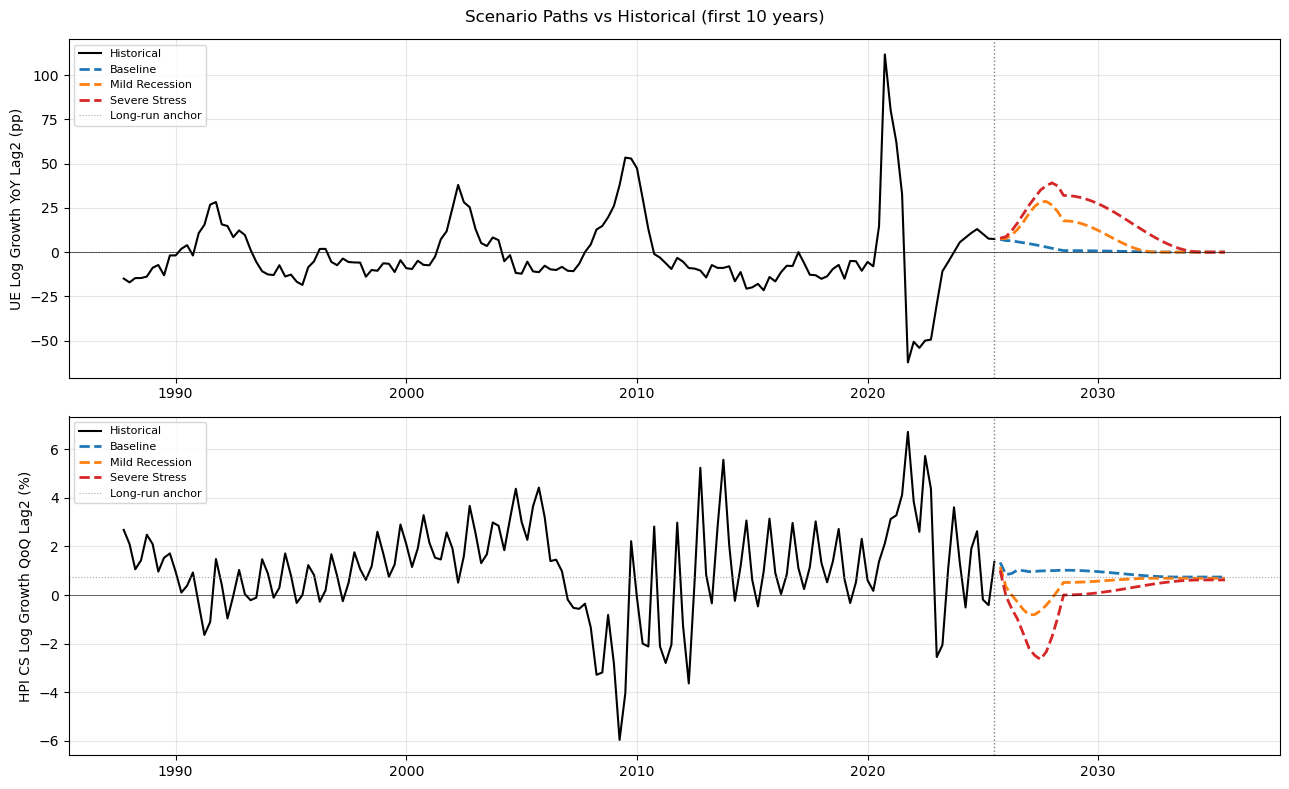

Peak stress -- first 12 quarters:
  BASELINE:
    unemployment_rate_log_diff_4_lag2                   min=+0.860  max=+7.221
    hpi_cs_log_diff_1_lag2                              min=+0.840  max=+1.340
    real_gdp_log_diff_4                                 min=+2.153  max=+2.407
  MILD:
    unemployment_rate_log_diff_4_lag2                   min=+7.596  max=+28.624
    hpi_cs_log_diff_1_lag2                              min=-0.816  max=+1.152
    real_gdp_log_diff_4                                 min=-0.292  max=+1.903
  SEVERE:
    unemployment_rate_log_diff_4_lag2                   min=+7.887  max=+39.093
    hpi_cs_log_diff_1_lag2                              min=-2.646  max=+1.006
    real_gdp_log_diff_4                                 min=-1.865  max=+1.689


In [22]:
UE_VAR  = 'unemployment_rate_log_diff_4_lag2'
HPI_VAR = 'hpi_cs_log_diff_1_lag2'

labels = {
    UE_VAR:  'UE Log Growth YoY Lag2 (pp)',
    HPI_VAR: 'HPI CS Log Growth QoQ Lag2 (%)',
}

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for ax, var in zip(axes, [UE_VAR, HPI_VAR]):
    ax.plot(
        bvar_data.index, bvar_data[var].values,
        color='black', linewidth=1.5, label='Historical'
    )
    for name, scen in SCENARIOS.items():
        ax.plot(
            all_paths[name].index[:40],
            all_paths[name][var].values[:40],
            color=scen['color'], linewidth=2,
            linestyle='--', label=scen['label']
        )
    ax.axvline(bvar_data.index.max(), color='gray', linewidth=1, linestyle=':')
    ax.axhline(long_run[var], color='gray', linewidth=0.8,
               linestyle=':', alpha=0.7, label='Long-run anchor')
    ax.axhline(0, color='k', linewidth=0.4)
    ax.set_ylabel(labels[var])
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Scenario Paths vs Historical (first 10 years)', fontsize=12)
fig.tight_layout()
plt.show()

print('Peak stress -- first 12 quarters:')
for name, path in all_paths.items():
    p12 = path.iloc[:12]
    print(f'  {name.upper()}:')
    for v in PD_VARS:
        print(f'    {v:<50}  '
              f'min={p12[v].min():+.3f}  max={p12[v].max():+.3f}')

## 17. Uncertainty Fan Charts
300 posterior predictive draws. Bands: 10-90% (light), 25-75% (dark).

## 17. Interval Calibration
Fan chart bands from raw posterior draws are typically overconfident.
The calibration finds a scale factor that makes historical 90% intervals
contain the realised value 90% of the time.

In [23]:
# ── Interval Calibration ─────────────────────────────────────────────
# Find scale factor so historical 90% intervals contain realised
# value ~90% of the time. Raw posterior draws are typically overconfident.

print('Running interval calibration...')
H_CHECK   = 4   # calibrate at 1-year horizon
N_CAL     = min(20, len(bvar_data) - H_CHECK - 5)
N_DRAWS   = 200
hits      = 0

for t in range(N_CAL):
    cutoff = len(bvar_data) - N_CAL + t
    train  = bvar_data.iloc[:cutoff]
    if len(train) < 20:
        continue
    try:
        m, _ = fit_stable(train, bvar.p, (bvar.lam,), bvar.alpha)
        draws  = m.forecast_draws(h=H_CHECK, n_draws=N_DRAWS, seed=0)
        actual = bvar_data.iloc[cutoff + H_CHECK - 1].values
        lo = np.percentile(draws[:, -1, :], 5,  axis=0)
        hi = np.percentile(draws[:, -1, :], 95, axis=0)
        hits += int(np.all((actual >= lo) & (actual <= hi)))
    except Exception:
        pass

empirical_cov = hits / max(N_CAL, 1)
CAL_SCALE     = 0.90 / max(empirical_cov, 0.10)
CAL_SCALE     = max(0.7, min(CAL_SCALE, 2.0))  # clamp

print(f'Calibration window : last {N_CAL} quarters at h={H_CHECK}')
print(f'Empirical 90% cov  : {empirical_cov:.3f}')
print(f'Calibration scale  : {CAL_SCALE:.3f}')
print('(scale > 1 = widen bands; scale < 1 = narrow)')

Running interval calibration...
BVAR: 6 vars, p=3, T=129, lam=0.15
Max eigenvalue: 0.926423  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=130, lam=0.15
Max eigenvalue: 0.931984  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=131, lam=0.15
Max eigenvalue: 0.927925  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=132, lam=0.15
Max eigenvalue: 0.900869  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=133, lam=0.15
Max eigenvalue: 0.908386  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=134, lam=0.15
Max eigenvalue: 0.894654  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=135, lam=0.15
Max eigenvalue: 0.891230  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=136, lam=0.15
Max eigenvalue: 0.883884  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=137, lam=0.15
Max eigenvalue: 0.890760  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=138, lam=0.15
Max eigenvalue: 0.896135  Stable
Using: p=3, lam=0.15
BVAR: 6 vars, p=3, T=139, lam=0.15
Max eigenvalue: 0.875840  Stable
Using: p=3

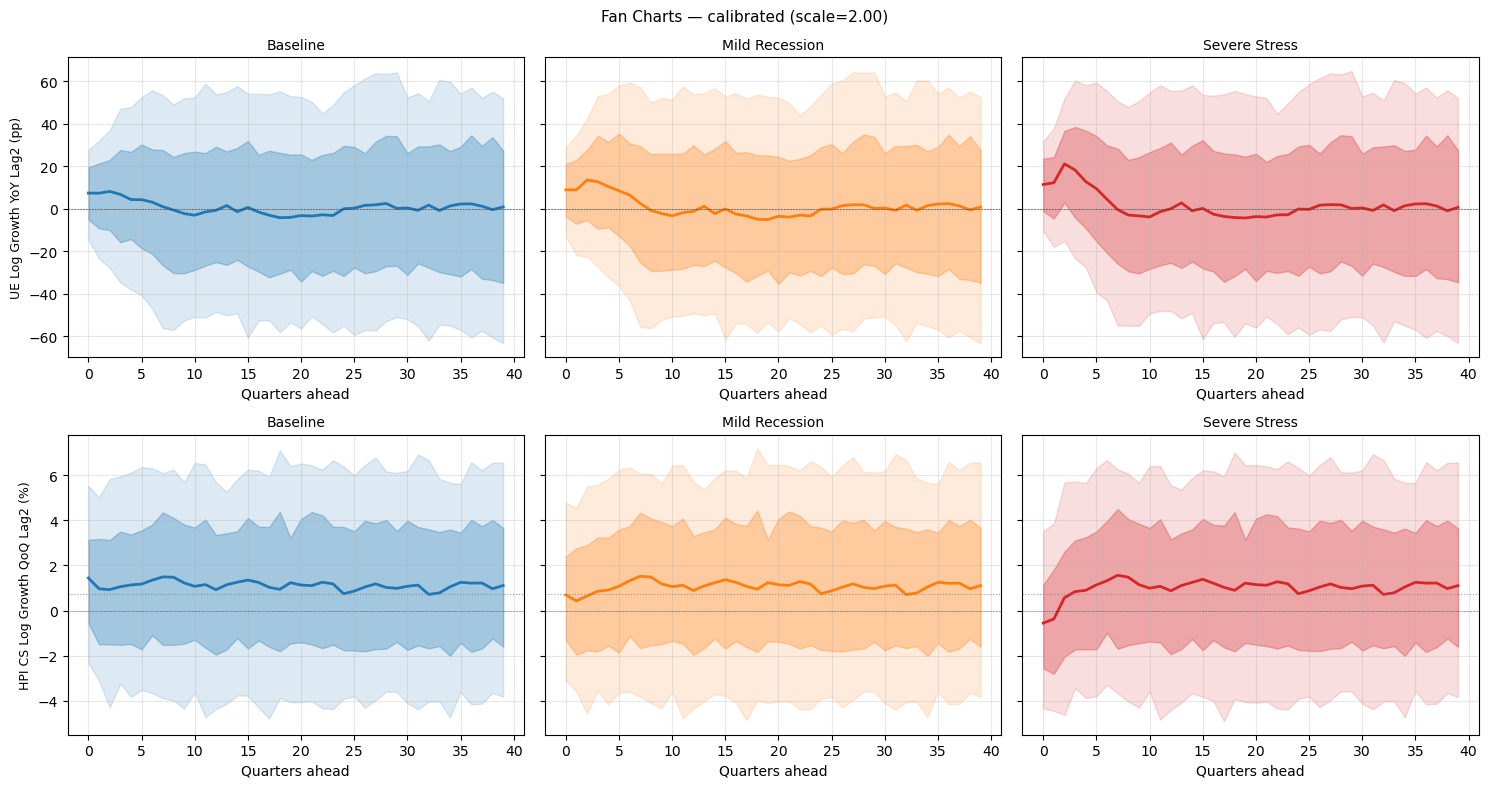

In [24]:
H_FAN = 40
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey='row')

PLOT_VARS   = ['unemployment_rate_log_diff_4_lag2', 'hpi_cs_log_diff_1_lag2']
labels_plot = {
    'unemployment_rate_log_diff_4_lag2': 'UE Log Growth YoY Lag2 (pp)',
    'hpi_cs_log_diff_1_lag2':            'HPI CS Log Growth QoQ Lag2 (%)',
}

for col, (name, scen) in enumerate(SCENARIOS.items()):
    draws = bvar.forecast_draws(h=H_FAN, n_draws=300,
                                shock=scen['shock'], seed=42)
    for row, var in enumerate(PLOT_VARS):
        ax = axes[row, col]
        vi = BVAR_VARS.index(var)
        d  = draws[:, :, vi]

        med   = np.median(d, axis=0)
        d_cal = med + (d - med) * CAL_SCALE

        ax.fill_between(range(H_FAN),
                        np.percentile(d_cal, 10, axis=0),
                        np.percentile(d_cal, 90, axis=0),
                        alpha=0.15, color=scen['color'])
        ax.fill_between(range(H_FAN),
                        np.percentile(d_cal, 25, axis=0),
                        np.percentile(d_cal, 75, axis=0),
                        alpha=0.30, color=scen['color'])
        ax.plot(med, color=scen['color'], linewidth=2)
        ax.axhline(long_run[var], color='gray', linewidth=0.8,
                   linestyle=':', alpha=0.8)
        ax.axhline(0, color='k', linewidth=0.4, linestyle='--', alpha=0.5)
        ax.set_title(scen['label'], fontsize=10)
        if col == 0:
            ax.set_ylabel(labels_plot[var], fontsize=9)
        ax.set_xlabel('Quarters ahead')
        ax.grid(True, alpha=0.3)

fig.suptitle(f'Fan Charts — calibrated (scale={CAL_SCALE:.2f})', fontsize=11)
fig.tight_layout()
plt.show()

## 18. Save

In [25]:
# ── Save BVAR bundle ─────────────────────────────────────────────────
with open('bvar_results.pkl', 'wb') as f:
    pickle.dump({
        'model':     bvar,
        'data':      bvar_data,
        'long_run':  long_run,
        'bvar_vars': BVAR_VARS,
        'pd_vars':   PD_VARS,
        'max_eig':   max_eig,
        'irfs':      irfs,
        'cal_scale': CAL_SCALE,
    }, f)
print('Saved: bvar_results.pkl')

# ── Export scenarios.csv ──────────────────────────────────────────────
# PD_VARS are a direct subset of BVAR_VARS so no transformation is needed.
# The same stationary transforms the BVAR projected are exactly what
# the PD model expects as inputs.

export_cols = ['scenario'] + PD_VARS
export = pd.concat([
    path[PD_VARS].assign(scenario=name)
    for name, path in all_paths.items()
])[export_cols].copy()
export.index.name = 'quarter'
export.to_csv('scenarios.csv')

print('Saved: scenarios.csv')
print(f'  Shape     : {export.shape}')
print(f'  Scenarios : {export["scenario"].unique().tolist()}')
print(f'  Columns   : {export.columns.tolist()}')
print(f'  Range     : {export.index.min()} to {export.index.max()}')

print('\nFirst 4 quarters per scenario:')
for name in ['baseline', 'mild', 'severe']:
    sub = export[export['scenario'] == name][PD_VARS].head(4)
    print(f'\n{name}:')
    print(sub.round(4).to_string())

Saved: bvar_results.pkl
Saved: scenarios.csv
  Shape     : (360, 4)
  Scenarios : ['baseline', 'mild', 'severe']
  Columns   : ['scenario', 'unemployment_rate_log_diff_4_lag2', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4']
  Range     : 2025-10-01 00:00:00 to 2055-07-01 00:00:00

First 4 quarters per scenario:

baseline:
            unemployment_rate_log_diff_4_lag2  hpi_cs_log_diff_1_lag2  real_gdp_log_diff_4
quarter                                                                                   
2025-10-01                             7.2205                  1.3398               2.1531
2026-01-01                             6.5159                  0.8396               2.2211
2026-04-01                             6.3924                  0.8847               2.2211
2026-07-01                             5.8345                  1.0253               2.1877

mild:
            unemployment_rate_log_diff_4_lag2  hpi_cs_log_diff_1_lag2  real_gdp_log_diff_4
quarter                       